In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------------
# Paths
# --------------------------------------------------

DATA_DIR = Path(
    "/Users/neda/Documents/Projects/2027_ICPhS (2)/data"
)


# --------------------------------------------------
# Load hand-crafted representations
# --------------------------------------------------

df_rhythm = pd.read_csv(
    DATA_DIR / "df_rhythm_persian.csv"
)

df_egemaps = pd.read_csv(
    DATA_DIR / "persian_egemaps_features.csv"
)


# --------------------------------------------------
# Initial inspection
# --------------------------------------------------

print("Rhythm shape:", df_rhythm.shape)
display(df_rhythm.head())

print("\neGeMAPS shape:", df_egemaps.shape)
display(df_egemaps.head())


Rhythm shape: (210, 36)


,File_Name,Language,Speaker,Year_of_Birth,Age,Gender,ID,Task,percent_V,deltaV,...,varcoM_f0,varcoP_f0,std_int_peak,std_int_mean,nPVI_int_mean,rPVI_int_mean,nPVI_int_peak,rPVI_int_peak,varcoM_int,varcoP_int
0,P_1984_F_22_mf.Table,Persian,P22,1984,40,Female,P_1984_F_22,m(f),34.911467,0.065863,...,3.330818,4.331199,3.252073,3.273839,3.616497,2.477725,3.122346,2.248257,4.740672,4.500871
1,P_1984_F_22_mi.Table,Persian,P22,1984,40,Female,P_1984_F_22,m(i),41.647792,0.091662,...,3.072454,4.020044,3.714772,3.848121,4.185725,2.874938,3.217598,2.311941,5.531084,5.117501
2,P_1984_F_22_rf.Table,Persian,P22,1984,40,Female,P_1984_F_22,r(f),35.853487,0.031060,...,3.647513,4.377586,3.228572,3.494776,4.532859,3.137796,3.498564,2.569650,4.997392,4.392098
3,P_1984_F_22_ri.Table,Persian,P22,1984,40,Female,P_1984_F_22,r(i),38.046579,0.037567,...,3.963287,4.517739,4.368131,4.437188,5.063604,3.541303,4.451029,3.275942,6.235604,5.839005
4,P_1984_F_22_sc.Table,Persian,P22,1984,40,Female,P_1984_F_22,con,35.492986,0.062758,...,4.193059,4.619762,4.307762,4.239625,4.387421,3.031325,3.739540,2.703945,6.075201,5.890475



eGeMAPS shape: (210, 93)


,speaker,task,file,feature_set,feature_level,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,P_1984_F_22,con,/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,30.840261,0.206127,29.507471,32.280730,35.195034,...,-0.028468,-0.004294,0.240401,3.707971,2.138141,0.318725,0.288210,0.141793,0.296321,-23.748556
1,P_1984_F_22,m(f),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,31.837244,0.162490,30.975094,32.620117,34.096195,...,-0.023735,-0.007394,0.188482,3.647944,1.854266,0.343047,0.364948,0.203273,0.605981,-25.320765
2,P_1984_F_22,m(i),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,31.966824,0.162195,30.828010,32.912200,35.221653,...,-0.030313,-0.005346,0.158577,3.117275,1.607805,0.372735,0.326186,0.261275,0.563466,-24.896715
3,P_1984_F_22,pic,/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,30.766730,0.170645,29.782148,31.453970,33.911420,...,-0.021049,-0.009475,0.193041,3.426791,1.958893,0.348409,0.304349,0.162183,0.290133,-25.175325
4,P_1984_F_22,r(f),/Users/neda/Documents/Corpus/Pertsch/persian/P...,eGeMAPSv02,Functionals,32.765984,0.149452,30.815640,33.042420,35.986153,...,-0.022317,-0.010229,0.257678,4.448354,2.514774,0.261950,0.224554,0.132791,0.281630,-23.980452


In [2]:
# --------------------------------------------------
# Harmonize speaker IDs
# --------------------------------------------------

df_rhythm["speaker_id"] = df_rhythm["Speaker"]

df_egemaps["speaker_id"] = (
    "P" + df_egemaps["speaker"].str.extract(r"_(\d{2})$")[0]
)


# --------------------------------------------------
# Define feature columns
# --------------------------------------------------

rhythm_metadata = [
    "File_Name",
    "Language",
    "Speaker",
    "Year_of_Birth",
    "Age",
    "Gender",
    "ID",
    "Task",
    "speaker_id",
]

egemaps_metadata = [
    "speaker",
    "task",
    "file",
    "feature_set",
    "feature_level",
    "speaker_id",
]

rhythm_features = [
    col for col in df_rhythm.columns
    if col not in rhythm_metadata
]

egemaps_features = [
    col for col in df_egemaps.columns
    if col not in egemaps_metadata
]


# --------------------------------------------------
# Basic checks
# --------------------------------------------------

print("Rhythm")
print("Recordings:", len(df_rhythm))
print("Speakers:", df_rhythm["speaker_id"].nunique())
print("Tasks:", df_rhythm["Task"].nunique())
print("Features:", len(rhythm_features))

print("\neGeMAPS")
print("Recordings:", len(df_egemaps))
print("Speakers:", df_egemaps["speaker_id"].nunique())
print("Tasks:", df_egemaps["task"].nunique())
print("Features:", len(egemaps_features))


# Check correspondence between datasets
rhythm_pairs = set(
    zip(df_rhythm["speaker_id"], df_rhythm["Task"])
)

egemaps_pairs = set(
    zip(df_egemaps["speaker_id"], df_egemaps["task"])
)

assert set(df_rhythm["speaker_id"]) == set(df_egemaps["speaker_id"])
assert rhythm_pairs == egemaps_pairs

print("\nSpeaker sets match.")
print("Speaker × task combinations match.")

Rhythm
Recordings: 210
Speakers: 30
Tasks: 7
Features: 28

eGeMAPS
Recordings: 210
Speakers: 30
Tasks: 7
Features: 88

Speaker sets match.
Speaker × task combinations match.


# Standardization and PCA

In [3]:
# --------------------------------------------------
# Standardization and PCA
# --------------------------------------------------

def fit_pca(df, features):
    X = df[features].to_numpy()

    # Z-standardize each acoustic feature
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Full PCA
    pca = PCA()
    scores = pca.fit_transform(X_scaled)

    # PCA diagnostics
    eigenvalues = pca.explained_variance_
    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    summary = pd.DataFrame({
        "PC": np.arange(1, len(eigenvalues) + 1),
        "Eigenvalue": eigenvalues,
        "Explained_variance": explained,
        "Cumulative_variance": cumulative
    })

    # Primary retention rule: Kaiser-Guttman
    n_retained = int(np.sum(eigenvalues > 1))

    return {
        "X_scaled": X_scaled,
        "scaler": scaler,
        "pca": pca,
        "scores": scores,
        "summary": summary,
        "eigenvalues": eigenvalues,
        "explained": explained,
        "cumulative": cumulative,
        "n_retained": n_retained,
    }

In [4]:
rhythm_pca = fit_pca(
    df_rhythm,
    rhythm_features
)

egemaps_pca = fit_pca(
    df_egemaps,
    egemaps_features
)

In [5]:
print("\nRhythm:")
print(
    rhythm_pca["summary"]
    .head(15)
    .round(4)
)

print("\neGeMAPS:")
print(
    egemaps_pca["summary"]
    .head(25)
    .round(4)
)


Rhythm:
    PC  Eigenvalue  Explained_variance  Cumulative_variance
0    1      8.6436              0.3072               0.3072
1    2      6.7129              0.2386               0.5458
2    3      4.6792              0.1663               0.7122
3    4      2.6503              0.0942               0.8064
4    5      1.1929              0.0424               0.8488
5    6      1.0185              0.0362               0.8850
6    7      0.7973              0.0283               0.9133
7    8      0.7431              0.0264               0.9397
8    9      0.6037              0.0215               0.9612
9   10      0.4321              0.0154               0.9765
10  11      0.2122              0.0075               0.9841
11  12      0.1809              0.0064               0.9905
12  13      0.1046              0.0037               0.9942
13  14      0.0674              0.0024               0.9966
14  15      0.0282              0.0010               0.9976

eGeMAPS:
    PC  Eigenvalue  E

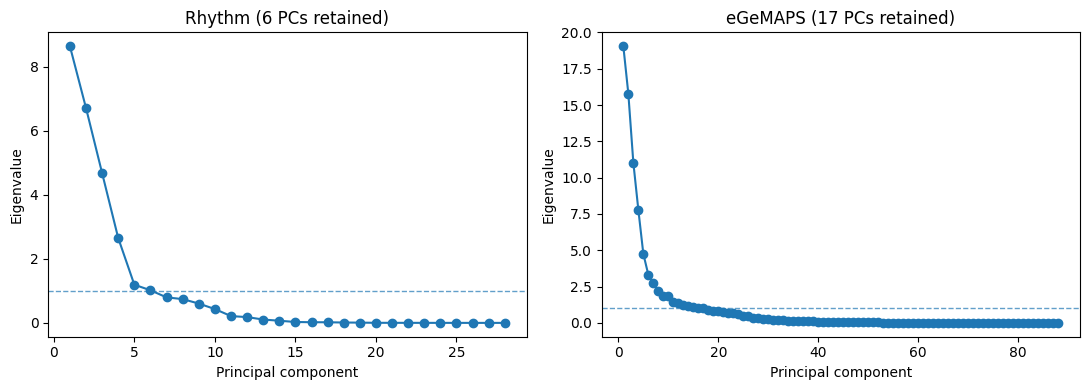

In [6]:
# --------------------------------------------------
# Scree plots for PCA retention
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

# Rhythm
axes[0].plot(
    rhythm_pca["summary"]["PC"],
    rhythm_pca["summary"]["Eigenvalue"],
    marker="o"
)

axes[0].axhline(
    1,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title(
    f"Rhythm ({rhythm_pca['n_retained']} PCs retained)"
)


# eGeMAPS
axes[1].plot(
    egemaps_pca["summary"]["PC"],
    egemaps_pca["summary"]["Eigenvalue"],
    marker="o"
)

axes[1].axhline(
    1,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

axes[1].set_xlabel("Principal component")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title(
    f"eGeMAPS ({egemaps_pca['n_retained']} PCs retained)"
)

plt.tight_layout()
plt.show()

In [7]:
def plot_speaker_pca(
    df,
    pca_result,
    speaker_col,
    task_col,
    highlight_speakers,
    title,
    ax=None
):
    scores = pca_result["scores"]

    plot_df = pd.DataFrame({
        "PC1": scores[:, 0],
        "PC2": scores[:, 1],
        "speaker": df[speaker_col].values,
        "task": df[task_col].values
    })

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7))

    # Background population
    other = plot_df[
        ~plot_df["speaker"].isin(highlight_speakers)
    ]

    ax.scatter(
        other["PC1"],
        other["PC2"],
        s=30,
        alpha=0.30,
        label="Other speakers"
    )

    # Highlight selected speakers
    for speaker in highlight_speakers:

        sp = plot_df[
            plot_df["speaker"] == speaker
        ]

        ax.scatter(
            sp["PC1"],
            sp["PC2"],
            s=75,
            alpha=0.95,
            label=speaker,
            zorder=3
        )

        # Task labels
        for _, row in sp.iterrows():
            ax.annotate(
                row["task"],
                (row["PC1"], row["PC2"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=10
            )

    pc1 = pca_result["explained"][0] * 100
    pc2 = pca_result["explained"][1] * 100

    ax.set_xlabel(
        f"PC1 ({pc1:.1f}% variance)"
    )

    ax.set_ylabel(
        f"PC2 ({pc2:.1f}% variance)"
    )

    ax.set_title(title)

    ax.axhline(
        0,
        linewidth=0.5,
        alpha=0.3
    )

    ax.axvline(
        0,
        linewidth=0.5,
        alpha=0.3
    )

    ax.legend()

    return plot_df

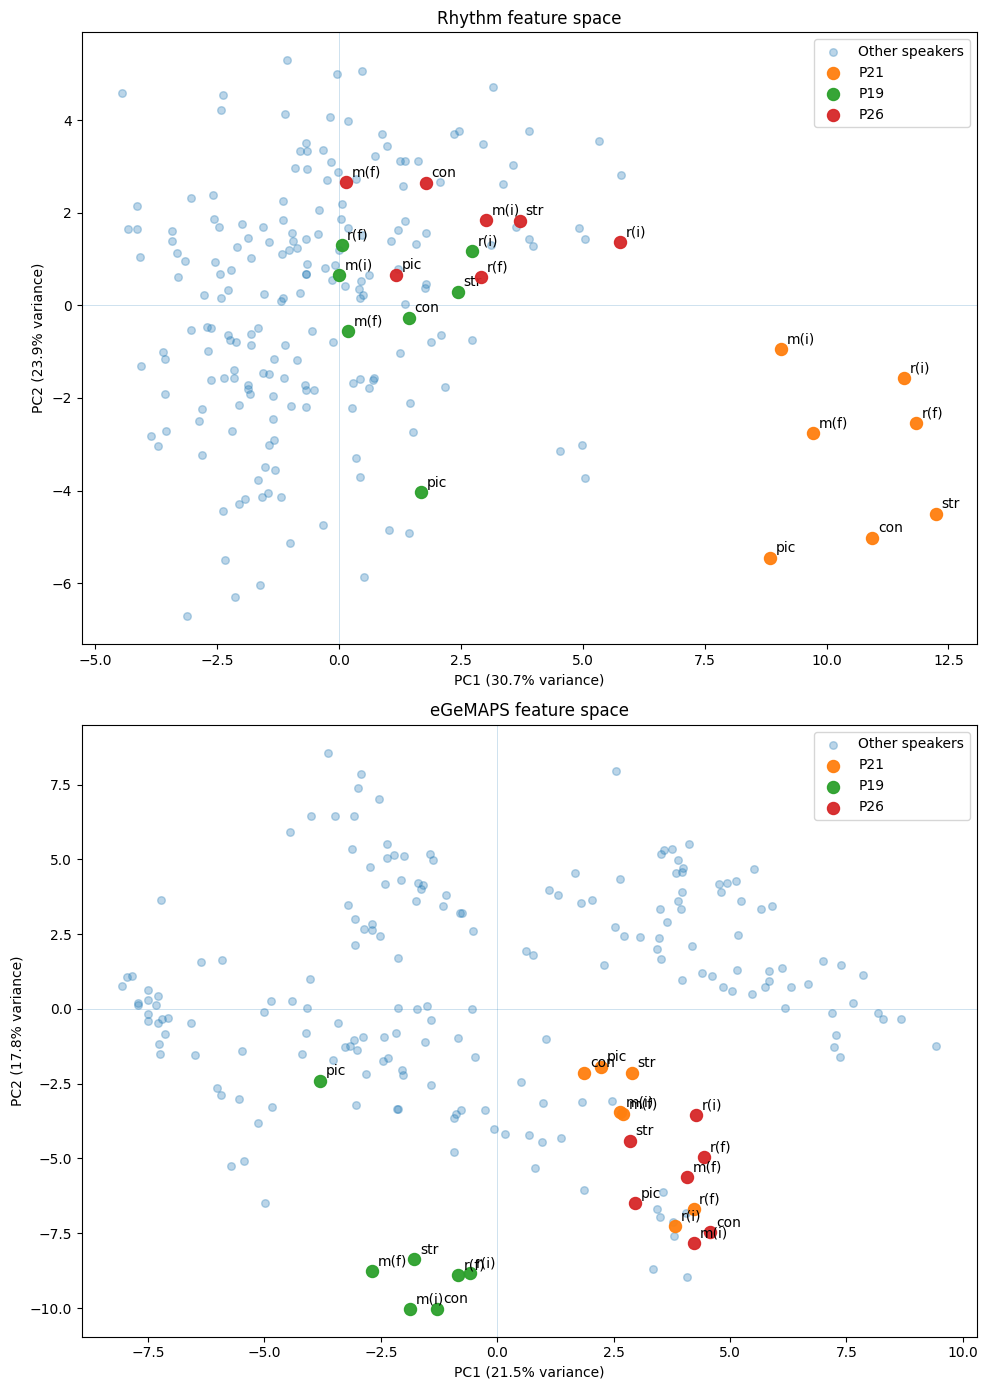

In [8]:
# --------------------------------------------------
# Combined PCA figure
# --------------------------------------------------

OUTPUT_DIR = Path(
    "/Users/neda/Documents/Projects/2027_ICPhS (2)/output"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 14)
)

rhythm_plot = plot_speaker_pca(
    df=df_rhythm,
    pca_result=rhythm_pca,
    speaker_col="speaker_id",
    task_col="Task",
    highlight_speakers=["P21", "P19", "P26"],
    title="Rhythm feature space",
    ax=axes[0]
)

egemaps_plot = plot_speaker_pca(
    df=df_egemaps,
    pca_result=egemaps_pca,
    speaker_col="speaker_id",
    task_col="task",
    highlight_speakers=["P21", "P19", "P26"],
    title="eGeMAPS feature space",
    ax=axes[1]
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "PCA_rhythm_eGeMAPS_vertical.pdf",
    bbox_inches="tight"
)

plt.show()

# --------------------------------------------------
# Within-speaker task dispersion
# --------------------------------------------------

In [20]:
# ==================================================
# WITHIN- AND BETWEEN-SPEAKER VARIABILITY
# ==================================================

import numpy as np
import pandas as pd

from scipy.spatial.distance import mahalanobis


# ==================================================
# 1. Within-speaker task variability
# ==================================================

def within_speaker_dispersion(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify within-speaker task variability as the mean
    Euclidean distance of a speaker's seven task recordings
    from that speaker's centroid in the retained PCA space.
    """

    # Use Kaiser-Guttman retention by default
    if k is None:
        k = pca_result["n_retained"]

    # Retained PCA scores
    scores = pca_result["scores"][:, :k]

    score_cols = [
        f"PC{i+1}" for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # --------------------------------------------------
    # Speaker-specific centroids
    # --------------------------------------------------

    speaker_centroids = (
        score_df
        .groupby("speaker_id")[score_cols]
        .transform("mean")
    )

    # Difference between each recording and
    # its speaker-specific centroid
    deviations = (
        score_df[score_cols]
        - speaker_centroids
    )

    # Euclidean distance from speaker centroid
    score_df["within_distance"] = np.sqrt(
        np.sum(
            deviations.to_numpy() ** 2,
            axis=1
        )
    )

    # --------------------------------------------------
    # Speaker-level within-speaker variability
    # --------------------------------------------------

    speaker_summary = (
        score_df
        .groupby("speaker_id")["within_distance"]
        .agg(
            mean_within_distance="mean",
            median_within_distance="median",
            sd_within_distance="std",
            min_within_distance="min",
            max_within_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = greatest within-speaker variability
    speaker_summary["within_rank"] = (
        speaker_summary["mean_within_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("within_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run within-speaker analysis
# --------------------------------------------------

rhythm_within, rhythm_speaker_within = (
    within_speaker_dispersion(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)

egemaps_within, egemaps_speaker_within = (
    within_speaker_dispersion(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


print("\nRhythm within-speaker task variability")
print(
    rhythm_speaker_within
    .round(3)
)

print("\neGeMAPS within-speaker task variability")
print(
    egemaps_speaker_within
    .round(3)
)


# ==================================================
# 2. Between-speaker differentiation
# ==================================================

def between_speaker_peripherality(
    df,
    pca_result,
    speaker_col,
    task_col,
    k=None
):
    """
    Quantify between-speaker differentiation using
    task-conditioned Mahalanobis distance.

    Each recording is compared with the population centroid
    for the corresponding speaking task. A common covariance
    matrix is estimated from all task-centered observations.
    """

    # Use Kaiser-Guttman retention by default
    if k is None:
        k = pca_result["n_retained"]

    # Retained PCA scores
    scores = pca_result["scores"][:, :k]

    score_cols = [
        f"PC{i+1}" for i in range(k)
    ]

    score_df = pd.DataFrame(
        scores,
        columns=score_cols
    )

    score_df["speaker_id"] = (
        df[speaker_col].values
    )

    score_df["task"] = (
        df[task_col].values
    )

    # --------------------------------------------------
    # Task-specific population centroids
    # --------------------------------------------------

    task_centroids = (
        score_df
        .groupby("task")[score_cols]
        .transform("mean")
    )

    # Center each recording on the centroid
    # of its corresponding task
    centered_scores = (
        score_df[score_cols]
        - task_centroids
    )

    # --------------------------------------------------
    # Common covariance matrix
    # --------------------------------------------------

    covariance = np.cov(
        centered_scores.to_numpy(),
        rowvar=False
    )

    # Pseudoinverse is robust to possible
    # near-singularity
    inverse_covariance = np.linalg.pinv(
        covariance
    )

    # --------------------------------------------------
    # Task-conditioned Mahalanobis distance
    # --------------------------------------------------

    # After task centering, the relevant task centroid
    # is the zero vector
    zero = np.zeros(k)

    score_df["between_distance"] = [
        mahalanobis(
            row,
            zero,
            inverse_covariance
        )
        for row in centered_scores.to_numpy()
    ]

    # --------------------------------------------------
    # Speaker-level between-speaker peripherality
    # --------------------------------------------------

    speaker_summary = (
        score_df
        .groupby("speaker_id")["between_distance"]
        .agg(
            mean_between_distance="mean",
            median_between_distance="median",
            sd_between_distance="std",
            min_between_distance="min",
            max_between_distance="max"
        )
        .reset_index()
    )

    # Rank 1 = most peripheral speaker
    speaker_summary["between_rank"] = (
        speaker_summary["mean_between_distance"]
        .rank(
            ascending=False,
            method="min"
        )
        .astype(int)
    )

    speaker_summary = (
        speaker_summary
        .sort_values("between_rank")
        .reset_index(drop=True)
    )

    return score_df, speaker_summary


# --------------------------------------------------
# Run between-speaker analysis
# --------------------------------------------------

rhythm_between, rhythm_speaker_between = (
    between_speaker_peripherality(
        df=df_rhythm,
        pca_result=rhythm_pca,
        speaker_col="speaker_id",
        task_col="Task"
    )
)

egemaps_between, egemaps_speaker_between = (
    between_speaker_peripherality(
        df=df_egemaps,
        pca_result=egemaps_pca,
        speaker_col="speaker_id",
        task_col="task"
    )
)


print("\nRhythm between-speaker peripherality")
print(
    rhythm_speaker_between
    .round(3)
)

print("\neGeMAPS between-speaker peripherality")
print(
    egemaps_speaker_between
    .round(3)
)


Rhythm within-speaker task variability
   speaker_id  mean_within_distance  median_within_distance  \
0         P12                 3.993                   4.791   
1         P30                 3.625                   3.288   
2         P11                 3.445                   3.581   
3         P29                 3.284                   3.673   
4         P16                 3.274                   4.002   
5         P20                 3.274                   3.762   
6         P22                 3.148                   3.141   
7         P14                 3.087                   2.773   
8         P10                 3.056                   2.930   
9         P21                 3.005                   2.718   
10        P18                 3.002                   3.071   
11        P02                 2.997                   3.178   
12        P15                 2.888                   2.512   
13        P24                 2.828                   2.946   
14        P05  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


# ==================================================
# CROSS-REPRESENTATION STATISTICAL ANALYSIS
# ==================================================

In [ ]:


from scipy.stats import spearmanr
import numpy as np
import pandas as pd


def compare_representations(
    rhythm_summary,
    egemaps_summary,
    value_col,
    rank_col,
    n_permutations=10_000,
    n_bootstrap=10_000,
    seed=42
):
    """
    Compare speaker-level values between rhythm and eGeMAPS.

    Returns:
        comparison_df
        results dictionary containing:
            Spearman rho
            permutation p-value
            bootstrap 95% CI
    """

    # --------------------------------------------------
    # Merge speakers across representations
    # --------------------------------------------------

    comparison = (
        rhythm_summary[
            ["speaker_id", value_col, rank_col]
        ]
        .rename(columns={
            value_col: "rhythm_value",
            rank_col: "rhythm_rank"
        })
        .merge(
            egemaps_summary[
                ["speaker_id", value_col, rank_col]
            ].rename(columns={
                value_col: "egemaps_value",
                rank_col: "egemaps_rank"
            }),
            on="speaker_id"
        )
    )

    x = comparison["rhythm_value"].to_numpy()
    y = comparison["egemaps_value"].to_numpy()

    # --------------------------------------------------
    # Observed Spearman correlation
    # --------------------------------------------------

    rho = spearmanr(x, y).statistic

    # --------------------------------------------------
    # Permutation test
    # --------------------------------------------------

    rng = np.random.default_rng(seed)

    permuted_rhos = np.empty(n_permutations)

    for i in range(n_permutations):
        permuted_rhos[i] = spearmanr(
            x,
            rng.permutation(y)
        ).statistic

    permutation_p = (
        np.sum(
            np.abs(permuted_rhos) >= np.abs(rho)
        ) + 1
    ) / (n_permutations + 1)

    # --------------------------------------------------
    # Speaker-level bootstrap confidence interval
    # --------------------------------------------------

    rng_boot = np.random.default_rng(seed)

    n_speakers = len(comparison)
    bootstrap_rhos = []

    for i in range(n_bootstrap):

        idx = rng_boot.choice(
            n_speakers,
            size=n_speakers,
            replace=True
        )

        x_boot = x[idx]
        y_boot = y[idx]

        # Avoid undefined Spearman correlations
        if (
            len(np.unique(x_boot)) > 1
            and len(np.unique(y_boot)) > 1
        ):
            bootstrap_rhos.append(
                spearmanr(
                    x_boot,
                    y_boot
                ).statistic
            )

    bootstrap_rhos = np.asarray(
        bootstrap_rhos
    )

    ci_low, ci_high = np.percentile(
        bootstrap_rhos,
        [2.5, 97.5]
    )

    results = {
        "rho": rho,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "permutation_p": permutation_p
    }

    return comparison, results


# ==================================================
# 1. Within-speaker variability:
#    rhythm vs eGeMAPS
# ==================================================

within_comparison, within_stats = (
    compare_representations(
        rhythm_summary=rhythm_speaker_within,
        egemaps_summary=egemaps_speaker_within,
        value_col="mean_within_distance",
        rank_col="within_rank"
    )
)


print("\nWITHIN-SPEAKER VARIABILITY")
print(
    f"Spearman rho = "
    f"{within_stats['rho']:.3f}"
)

print(
    f"95% bootstrap CI = "
    f"[{within_stats['ci_low']:.3f}, "
    f"{within_stats['ci_high']:.3f}]"
)

print(
    f"Permutation p = "
    f"{within_stats['permutation_p']:.4f}"
)


# ==================================================
# 2. Between-speaker peripherality:
#    rhythm vs eGeMAPS
# ==================================================

between_comparison, between_stats = (
    compare_representations(
        rhythm_summary=rhythm_speaker_between,
        egemaps_summary=egemaps_speaker_between,
        value_col="mean_between_distance",
        rank_col="between_rank"
    )
)


print("\nBETWEEN-SPEAKER PERIPHERALITY")
print(
    f"Spearman rho = "
    f"{between_stats['rho']:.3f}"
)

print(
    f"95% bootstrap CI = "
    f"[{between_stats['ci_low']:.3f}, "
    f"{between_stats['ci_high']:.3f}]"
)

print(
    f"Permutation p = "
    f"{between_stats['permutation_p']:.4f}"
)


WITHIN-SPEAKER VARIABILITY
Spearman rho = 0.220
95% bootstrap CI = [-0.178, 0.565]
Permutation p = 0.2489

BETWEEN-SPEAKER PERIPHERALITY
Spearman rho = 0.134
95% bootstrap CI = [-0.271, 0.498]
Permutation p = 0.4776


In [22]:
# ==================================================
# Summary table
# ==================================================

summary_stats = pd.DataFrame({
    "Measure": [
        "Within-speaker task variability",
        "Between-speaker peripherality"
    ],
    "Spearman_rho": [
        within_stats["rho"],
        between_stats["rho"]
    ],
    "CI_low": [
        within_stats["ci_low"],
        between_stats["ci_low"]
    ],
    "CI_high": [
        within_stats["ci_high"],
        between_stats["ci_high"]
    ],
    "Permutation_p": [
        within_stats["permutation_p"],
        between_stats["permutation_p"]
    ]
})

print(
    summary_stats.round(3).to_string(index=False)
)

                        Measure  Spearman_rho  CI_low  CI_high  Permutation_p
Within-speaker task variability         0.220  -0.178    0.565          0.249
  Between-speaker peripherality         0.134  -0.271    0.498          0.478


In [23]:
# ==================================================
# Rank-comparison plotting function
# ==================================================

import matplotlib.pyplot as plt


def plot_rank_comparison(
    comparison,
    xlabel,
    ylabel,
    title=None,
    save_path=None
):
    fig, ax = plt.subplots(
        figsize=(5, 5)
    )

    ax.scatter(
        comparison["rhythm_rank"],
        comparison["egemaps_rank"],
        s=35
    )

    # Identical-rank reference line
    ax.plot(
        [1, 30],
        [1, 30],
        linestyle="--",
        linewidth=0.8
    )

    # Speaker labels
    for _, row in comparison.iterrows():
        ax.annotate(
            row["speaker_id"],
            (
                row["rhythm_rank"],
                row["egemaps_rank"]
            ),
            fontsize=7,
            xytext=(3, 3),
            textcoords="offset points"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Rank 1 = highest variability/peripherality
    ax.set_xlim(30.5, 0.5)
    ax.set_ylim(30.5, 0.5)

    ax.set_xticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_yticks(
        [30, 25, 20, 15, 10, 5, 1]
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    if title is not None:
        ax.set_title(title)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            bbox_inches="tight"
        )

    plt.show()

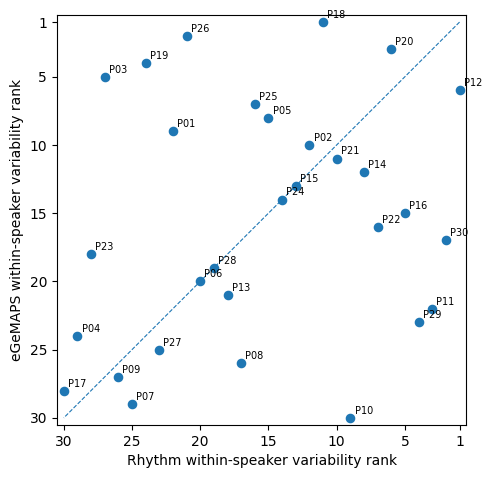

In [24]:
# ==================================================
# Within-speaker rank comparison
# ==================================================

plot_rank_comparison(
    comparison=within_comparison,
    xlabel="Rhythm within-speaker variability rank",
    ylabel="eGeMAPS within-speaker variability rank",
    save_path="within_speaker_rank_comparison.pdf"
)

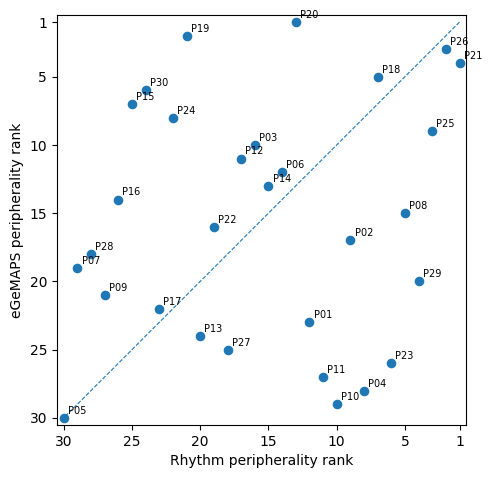

In [25]:
# ==================================================
# Between-speaker rank comparison
# ==================================================

plot_rank_comparison(
    comparison=between_comparison,
    xlabel="Rhythm peripherality rank",
    ylabel="eGeMAPS peripherality rank",
    save_path="between_speaker_rank_comparison.pdf"
)

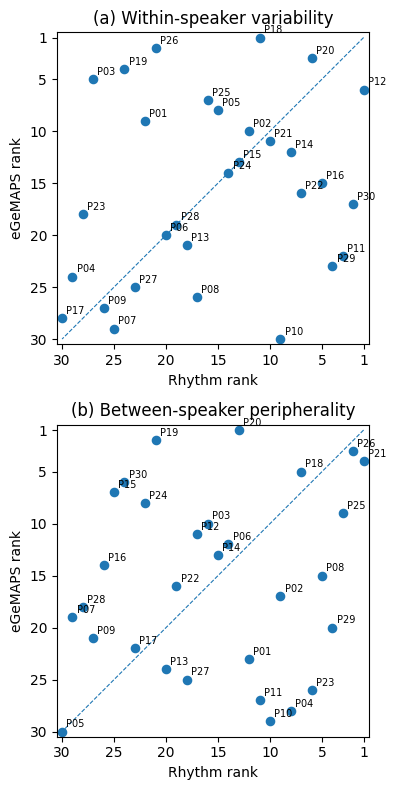

In [30]:
# ==================================================
# Combined within/between rank figure — vertical
# ==================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(5, 8)
)


# --------------------------------------------------
# Panel A: within-speaker variability
# --------------------------------------------------

ax = axes[0]

ax.scatter(
    within_comparison["rhythm_rank"],
    within_comparison["egemaps_rank"],
    s=35
)

ax.plot(
    [1, 30],
    [1, 30],
    linestyle="--",
    linewidth=0.8
)

for _, row in within_comparison.iterrows():
    ax.annotate(
        row["speaker_id"],
        (
            row["rhythm_rank"],
            row["egemaps_rank"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.set_xlabel("Rhythm rank")
ax.set_ylabel("eGeMAPS rank")
ax.set_title("(a) Within-speaker variability")

# Rank 1 = greatest variability
ax.set_xlim(30.5, 0.5)
ax.set_ylim(30.5, 0.5)

ax.set_xticks([30, 25, 20, 15, 10, 5, 1])
ax.set_yticks([30, 25, 20, 15, 10, 5, 1])

ax.set_aspect(
    "equal",
    adjustable="box"
)


# --------------------------------------------------
# Panel B: between-speaker peripherality
# --------------------------------------------------

ax = axes[1]

ax.scatter(
    between_comparison["rhythm_rank"],
    between_comparison["egemaps_rank"],
    s=35
)

ax.plot(
    [1, 30],
    [1, 30],
    linestyle="--",
    linewidth=0.8
)

for _, row in between_comparison.iterrows():
    ax.annotate(
        row["speaker_id"],
        (
            row["rhythm_rank"],
            row["egemaps_rank"]
        ),
        fontsize=7,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.set_xlabel("Rhythm rank")
ax.set_ylabel("eGeMAPS rank")
ax.set_title("(b) Between-speaker peripherality")

# Rank 1 = greatest peripherality
ax.set_xlim(30.5, 0.5)
ax.set_ylim(30.5, 0.5)

ax.set_xticks([30, 25, 20, 15, 10, 5, 1])
ax.set_yticks([30, 25, 20, 15, 10, 5, 1])

ax.set_aspect(
    "equal",
    adjustable="box"
)


# --------------------------------------------------
# Save
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "within_between_rank_comparison_vertical.pdf",
    bbox_inches="tight"
)

plt.show()

# Learned representation